Assignment: Sales forecast based on Advertising Spend using Linear Regression

Source Data: advertising_spend.csv

Sample Data:

Advertising Spend ($) Sales Revenue ($)

2743.579875     10562.77514

8798.436865     29248.94671

7994.517614     28648.51617

6618.673163     22403.00689

8520.759118     33363.2003

8686.21259      35185.25565

Requirement:

a. Predict product sales based on advertising spend using Linear Regression

b. Generate a heat map of Advertising Spend Vs Sales Revenue

c. Visualize the data as a scatter plot with a regression line

d. Compute Mean Squared Error, Absolute Mean Error & R2 Score

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

a. Predict product sales based on advertising spend using Linear Regression

In [3]:
advertising_pd = pd.read_csv('../data/advertising_spend.csv')
advertising_pd.head()

,Advertising Spend ($),Sales Revenue ($)
0,2743.579875,10562.775144
1,8798.436865,29248.946706
2,7994.517614,28648.516173
3,6618.673163,22403.006889
4,8520.759118,33363.200297


In [ ]:
adv_data = advertising_pd['Advertising Spend ($)']
sales_data = advertising_pd['Sales Revenue ($)']


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(adv_data.values.reshape(-1, 1), sales_data.values, test_size=0.2, random_state=42)

X_train.shape


(400, 1)

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
print(lr.intercept_)
print(lr.coef_)

1014.2710954066097
[3.41740416]


In [15]:
X_test[:5]

array([[4048.34553088],
       [6836.94309054],
       [2510.47473611],
       [7094.10969222],
       [9216.39369338]])

In [16]:
y_test[:5]

array([ 8831.54478681, 14919.39862899,  9758.58308426, 21913.99672993,
       43043.91899314])

In [17]:
pred_y = lr.predict(X_test)

In [27]:
#predicting a value

advertising_spend = 8520.759118
predicted_sales = lr.predict([[advertising_spend]])
print(f"Predicted sales revenue for an advertising spend of ${advertising_spend}: ${predicted_sales[0]:.2f}")

Predicted sales revenue for an advertising spend of $8520.759118: $30133.15


In [18]:
pred_y[:5]

array([14849.1039386 , 24378.86882911,  9593.57789275, 25257.71104254,
       32510.41320884])

b. Generate a heat map of Advertising Spend Vs Sales Revenue

<Axes: >

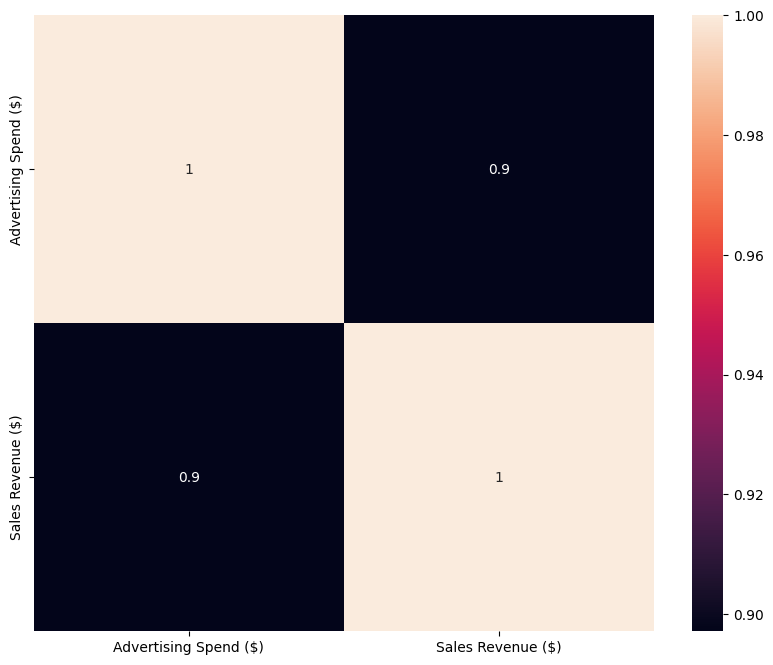

In [23]:
corr_mat = advertising_pd.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(data = corr_mat, annot = True, ax=ax)


c. Visualize the data as a scatter plot with a regression line

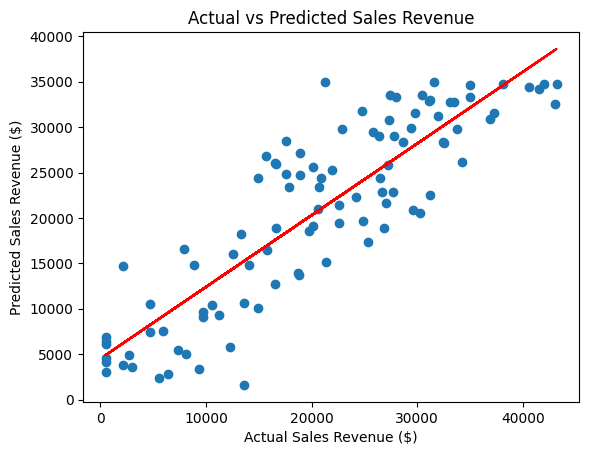

In [31]:
from numpy.polynomial import Polynomial

fig, ax1 = plt.subplots()
ax1.scatter(y_test,pred_y)

p = Polynomial.fit(y_test, pred_y, deg = 1)
ax1.plot(y_test, p(y_test), color = 'red')
ax1.set_xlabel('Actual Sales Revenue ($)')
ax1.set_ylabel('Predicted Sales Revenue ($)')
ax1.set_title('Actual vs Predicted Sales Revenue')
plt.show()

d. Compute Mean Squared Error, Absolute Mean Error & R2 Score

In [34]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [35]:
mean_absolute_error(y_test, pred_y)

4573.577538723408

In [36]:
mean_squared_error(y_test, pred_y)

30888754.70109166

In [37]:
r2_score(y_test, pred_y)

0.7592517676013648